In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.linalg import svd
import torch
from dtuimldmtools import rlr_validate, draw_neural_net, train_neural_net
from sklearn import model_selection

save_dir = 'plots'
os.makedirs('plots', exist_ok=True)  # Create the directory if it doesn't exist

# Open and filter data

In [5]:
# Read the data
df = pd.read_csv(
    '../dataset/auto-mpg.data',
    sep=r'\s+',
    names=[
        "mpg", "cylinders", "displacement", "horsepower",
        "weight", "acceleration", "model_year", "origin", "car_name"
    ],
    na_values=['?']  # Converts only '?' to NaN
).dropna()

# from https://github.com/Munees11/Auto-MPG-prediction/blob/master/Scripts/Auto%20MPG%20Predictions.ipynb
# df['brand'] = df["car_name"].str.extract('(^.*?)\s')
# df["origin"] = df["origin"].apply(lambda x: "USA" if x == 1 else ("Europe" if x == 2 else "Japan"))

# Drop the non-continuous columns
continous_columns = [col for col in df.columns if col not in ['model_year', 'origin', 'car_name']]
df_continous = df[continous_columns].copy()

# Drop the non-numerical columns
numerical_columns = [col for col in df.columns if col not in ['car_name']]
df_numerical = df[numerical_columns].copy()

# Make the cylinders attribute as continuous
df_continous['cylinders'] = (df_continous['cylinders'] - df_continous['cylinders'].min()) / (df_continous['cylinders'].max() - df_continous['cylinders'].min())
df_numerical['cylinders'] = (df_numerical['cylinders'] - df_numerical['cylinders'].min()) / (df_numerical['cylinders'].max() - df_numerical['cylinders'].min())

df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


# Data representation

## General pairplot
Numerical non-standardized

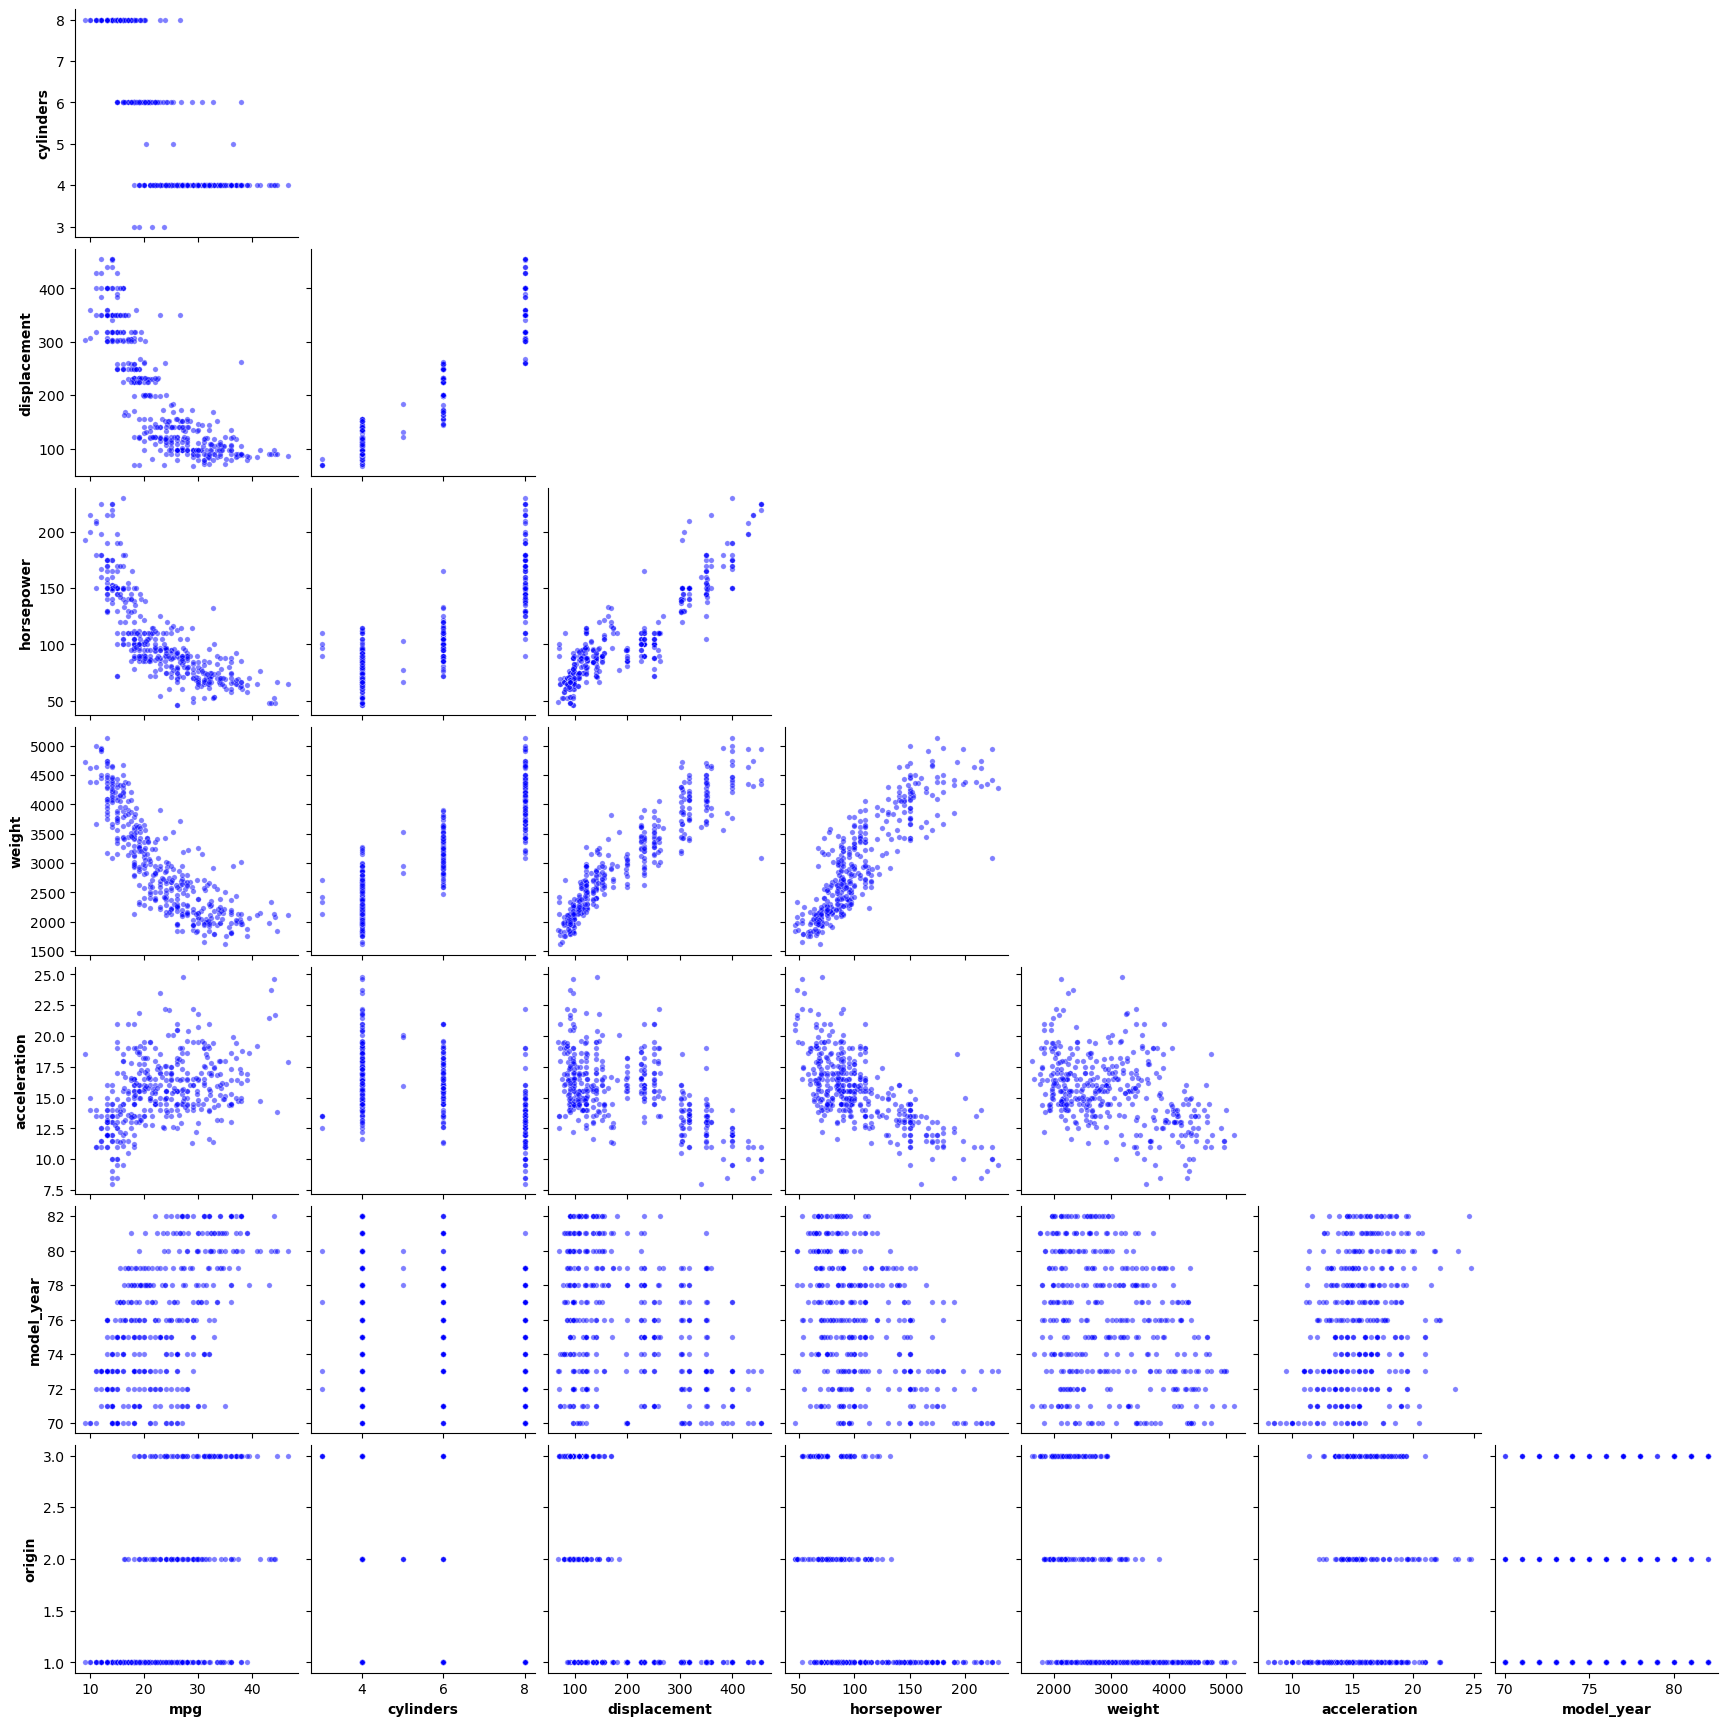

In [6]:
# Create pairplot without histograms, showing only scatter plots with adjusted point size and transparency
pairplot = sns.pairplot(
    data=df[numerical_columns],
    corner=True, diag_kind=None,
    plot_kws={'color': 'blue', 's': 15, 'alpha': 0.5}  # Set scatter point size and transparency
)

# Remove all plots on the diagonal
for i in range(len(pairplot.axes)):
   if pairplot.axes[i][i] is not None:
      pairplot.axes[i][i].set_visible(False)

# Adjust titles, labels, and font sizes for better readability

for ax in pairplot.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=10, fontweight='bold')
        ax.set_ylabel(ax.get_ylabel(), fontsize=10, fontweight='bold')

plt.savefig(os.path.join(save_dir, "Pairplot.png"), dpi=300, bbox_inches='tight')

## Boxplots
Only continous (cylinder standardized)

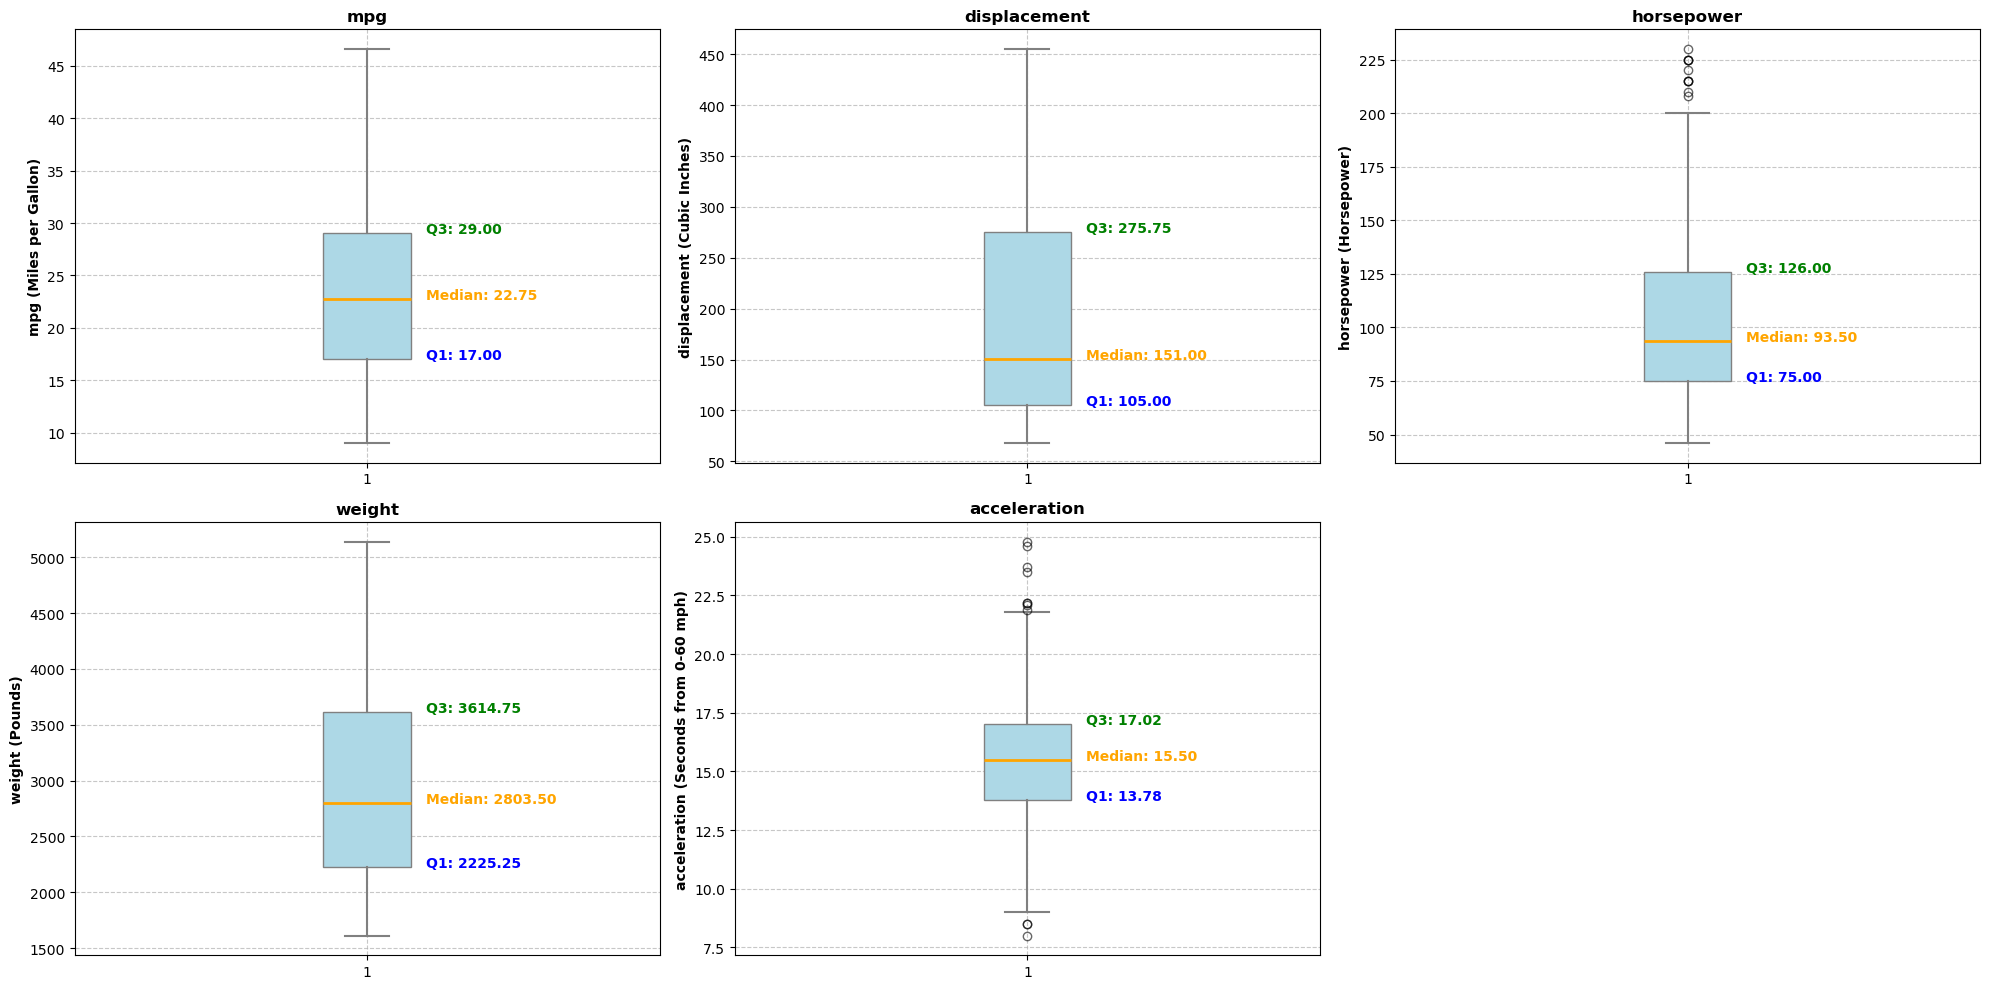

In [7]:
# Define units for each column (add units for other numerical columns if needed)
units = {
    "mpg": "Miles per Gallon",
    "cylinders": "Normalized # of cylinders [0-1]",
    "displacement": "Cubic Inches",
    "horsepower": "Horsepower",
    "weight": "Pounds",
    "acceleration": "Seconds from 0-60 mph",
    "model_year": "Year",
    "origin": "Origin"  # You might want to change this unit
}

# Calculate the number of rows and columns for subplots, excluding 'cylinders'
columns_to_plot = [col for col in df_continous.columns if col != 'cylinders']
num_cols = 3  # Adjust as needed
num_rows = int(np.ceil(len(columns_to_plot) / num_cols))

# Create figure and axes with adjusted figsize for horizontal spacing
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 5 * num_rows)) # Increased figsize width

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Iterate through numerical columns (excluding 'cylinders') and create box plots
for i, column in enumerate(columns_to_plot):
    ax = axes[i]  # Get the current subplot axis

    # Create the box plot with styling
    box = ax.boxplot(df_continous[column], patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='grey'),
                      medianprops=dict(color='orange', linewidth=2),
                      whiskerprops=dict(color='grey', linewidth=1.5),
                      capprops=dict(color='grey', linewidth=1.5),
                      flierprops=dict(marker='o', color='red', alpha=0.6))

    # Compute quartiles and median
    q1 = np.percentile(df_continous[column], 25)
    median = np.median(df_continous[column])
    q3 = np.percentile(df_continous[column], 75)

    # Annotate quartiles and median
    ax.text(1.1, q1, f"Q1: {q1:.2f}", color='blue', fontsize=10, fontweight='bold')
    ax.text(1.1, median, f"Median: {median:.2f}", color='orange', fontsize=10, fontweight='bold')
    ax.text(1.1, q3, f"Q3: {q3:.2f}", color='green', fontsize=10, fontweight='bold')

    # Set title and labels
    ax.set_title(column, fontsize=12, fontweight='bold')
    ax.set_ylabel(f"{column} ({units.get(column, '')})", fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "numerical_boxplots.png"), dpi=300, bbox_inches='tight')

## Histograms

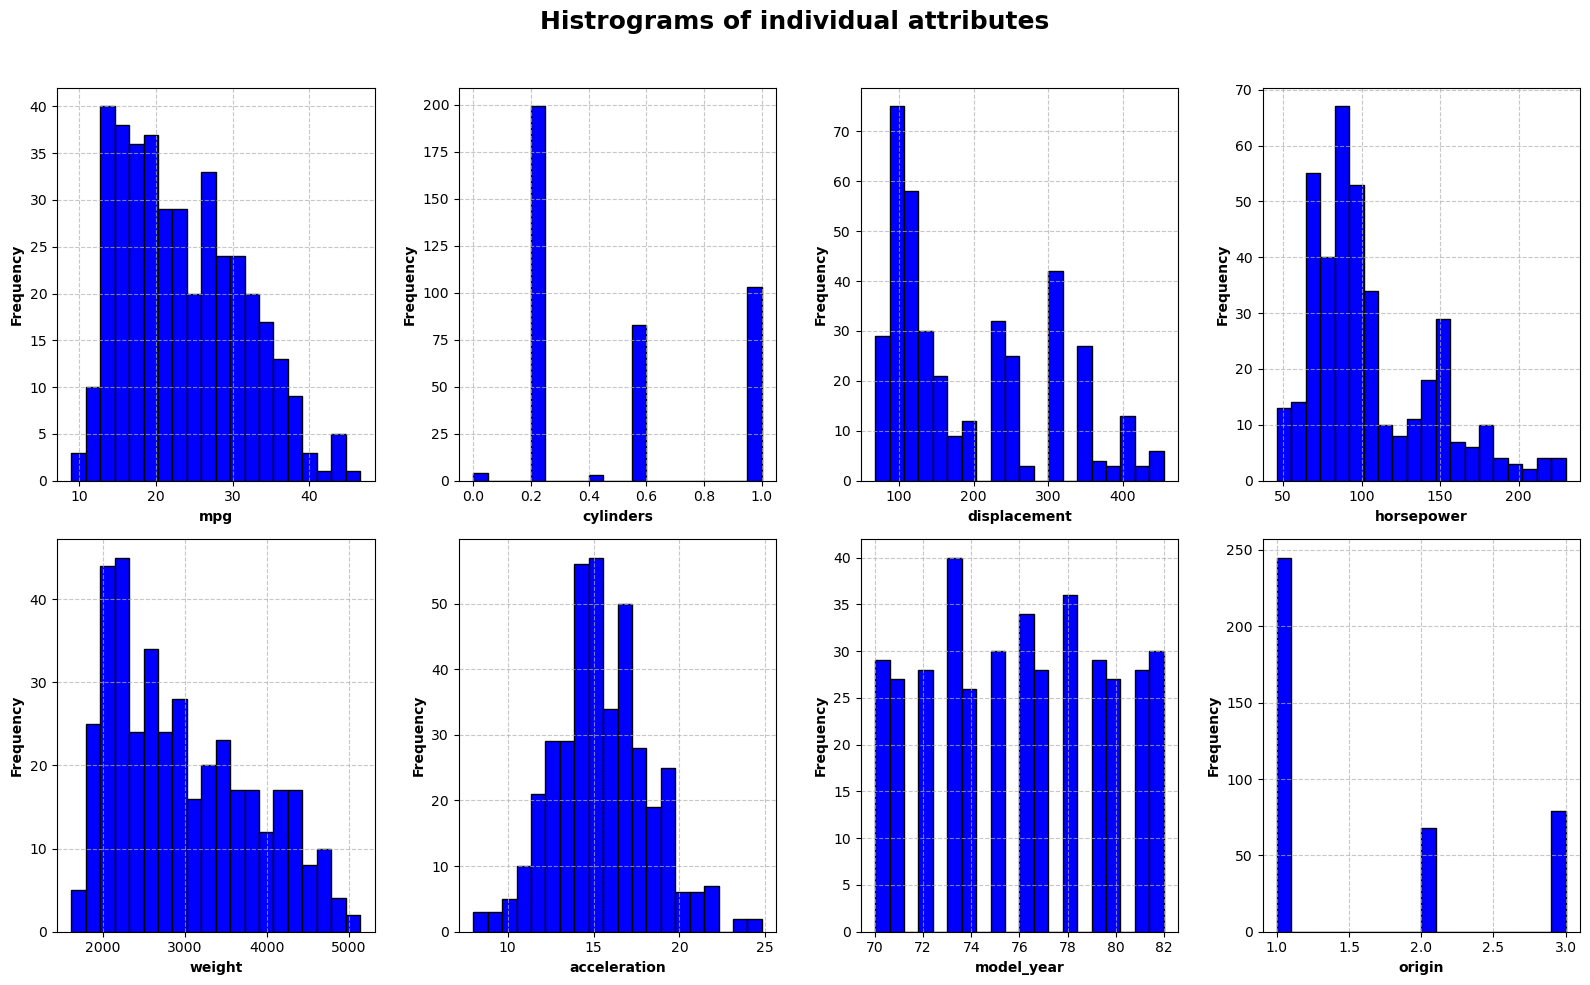

In [8]:
# Define the number of rows and columns for the subplot grid
num_cols = 4  # 4 plots per row
num_rows = 2  # 2 rows

# Create figure and axes
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 10))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Generate histograms for each column in df_cleaned (excluding 'car_name')
for i, column in enumerate(numerical_columns):
    axes[i].hist(df_numerical[column], bins=20, color='blue', edgecolor='black')
    axes[i].set_xlabel(column, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frequency', fontsize=10, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots (in case columns_to_plot < num_cols * num_rows)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Set a single main title for the whole figure
fig.suptitle("Histrograms of individual attributes", fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make space for title
plt.savefig(os.path.join(save_dir, "histograms.png"), dpi=300, bbox_inches="tight")  # Save all histograms as one image

## Acceleration by number of cylinders

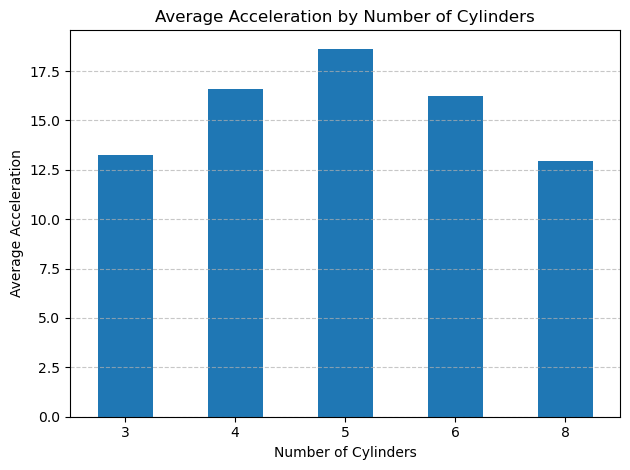

In [9]:
acceleration_by_cylinders = df.groupby('cylinders')['acceleration'].mean()
acceleration_by_cylinders.plot(kind='bar', title='Average Acceleration by Number of Cylinders')
plt.xlabel('Number of Cylinders')
plt.xticks(rotation=0)
plt.ylabel('Average Acceleration')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Horsepower based on number on cylinders

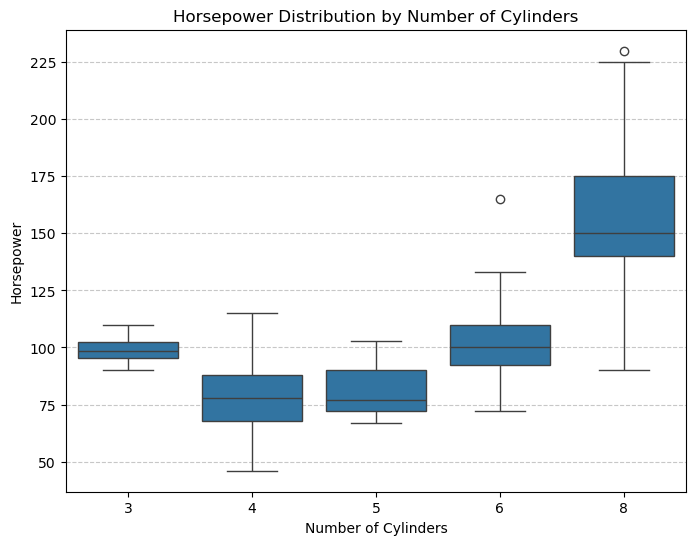

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='cylinders', y='horsepower', data=df)
plt.title('Horsepower Distribution by Number of Cylinders')
plt.xlabel('Number of Cylinders')
plt.ylabel('Horsepower')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(save_dir, "horsepower_boxplot.png"), dpi=300, bbox_inches='tight')
plt.show()


## MPG based on acceleration
Don't use the first one

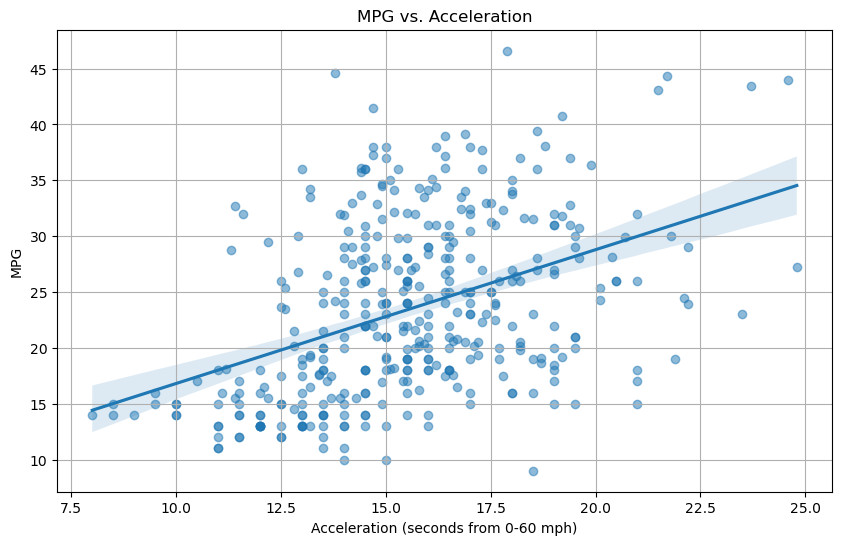

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(x='acceleration', y='mpg', data=df, scatter_kws={'alpha':0.5})
plt.xlabel('Acceleration (seconds from 0-60 mph)')
plt.ylabel('MPG')
plt.title('MPG vs. Acceleration')
plt.grid(True)
plt.show()


### Average

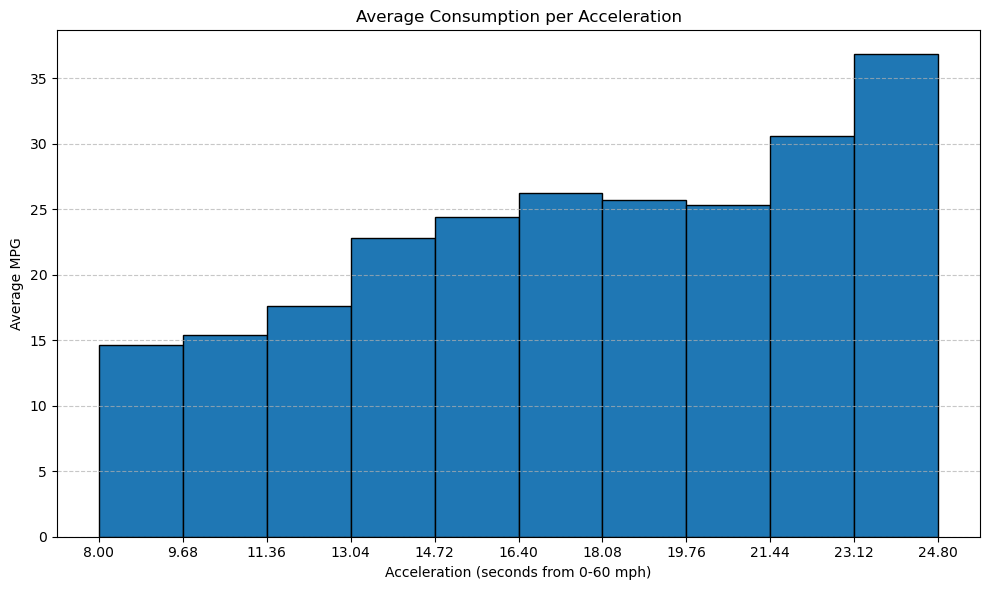

In [12]:
num_bins = 10

# Calculate histogram using np.histogram
hist, bin_edges = np.histogram(df['acceleration'], bins=num_bins)

# Calculate average MPG per bin
avg_mpg_by_bin = []
for i in range(num_bins):
  bin_data = df[(df['acceleration'] >= bin_edges[i]) & (df['acceleration'] < bin_edges[i + 1])]
  avg_mpg_by_bin.append(bin_data['mpg'].mean())

# Create the bar plot with bars next to each other
plt.figure(figsize=(10, 6))
plt.bar(bin_edges[:-1], avg_mpg_by_bin, width=np.diff(bin_edges), edgecolor='black', align='edge')
plt.ylabel('Average MPG')
plt.xlabel('Acceleration (seconds from 0-60 mph)')
plt.title('Average Consumption per Acceleration')
plt.xticks(bin_edges, ha='center')  # Use bin_edges for tick positions
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## Classificating origin

### Pairplot

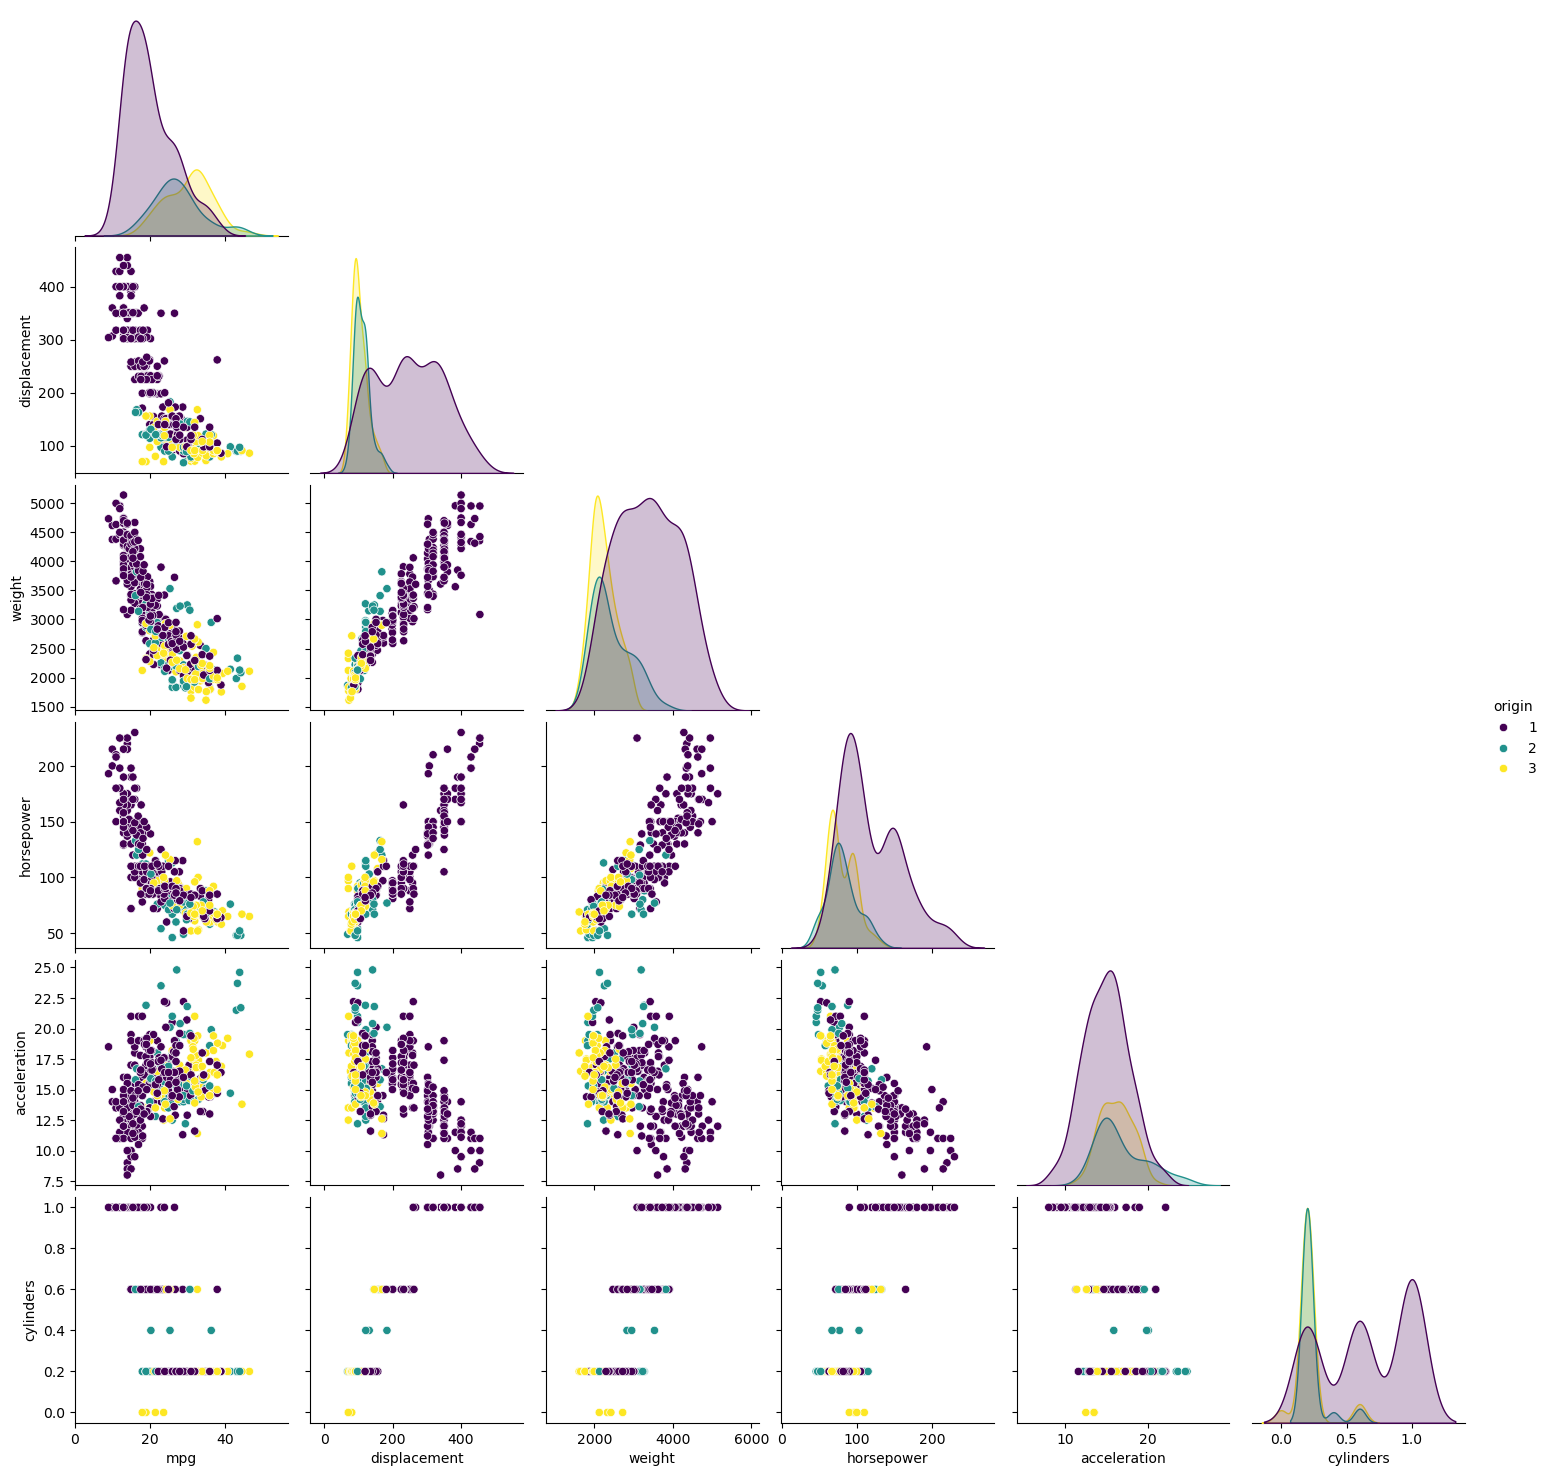

In [13]:
import seaborn as sns

# Select relevant features
features = ["mpg", "displacement", "weight", "horsepower", "acceleration", "cylinders"]
target = "origin"

# Pairplot with hue = origin
sns.pairplot(df_numerical, vars=features, hue=target, palette="viridis", diag_kind="kde", corner=True)
plt.show()

### From MPG



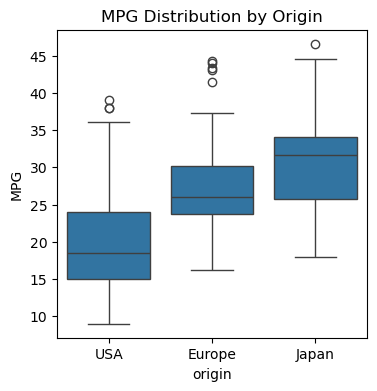

In [14]:
plt.figure(figsize=(4, 4))
sns.boxplot(x='origin', y='mpg', data=df)
# plt.xlabel('Origin (Zone)')
plt.ylabel('MPG')
plt.title('MPG Distribution by Origin')
plt.xticks([0, 1, 2], ['USA', 'Europe', 'Japan']) #Set custom labels for clarity

plt.savefig(os.path.join(save_dir, "MPG_by_origin.png"), dpi=300, bbox_inches='tight')

## Predicting MPG

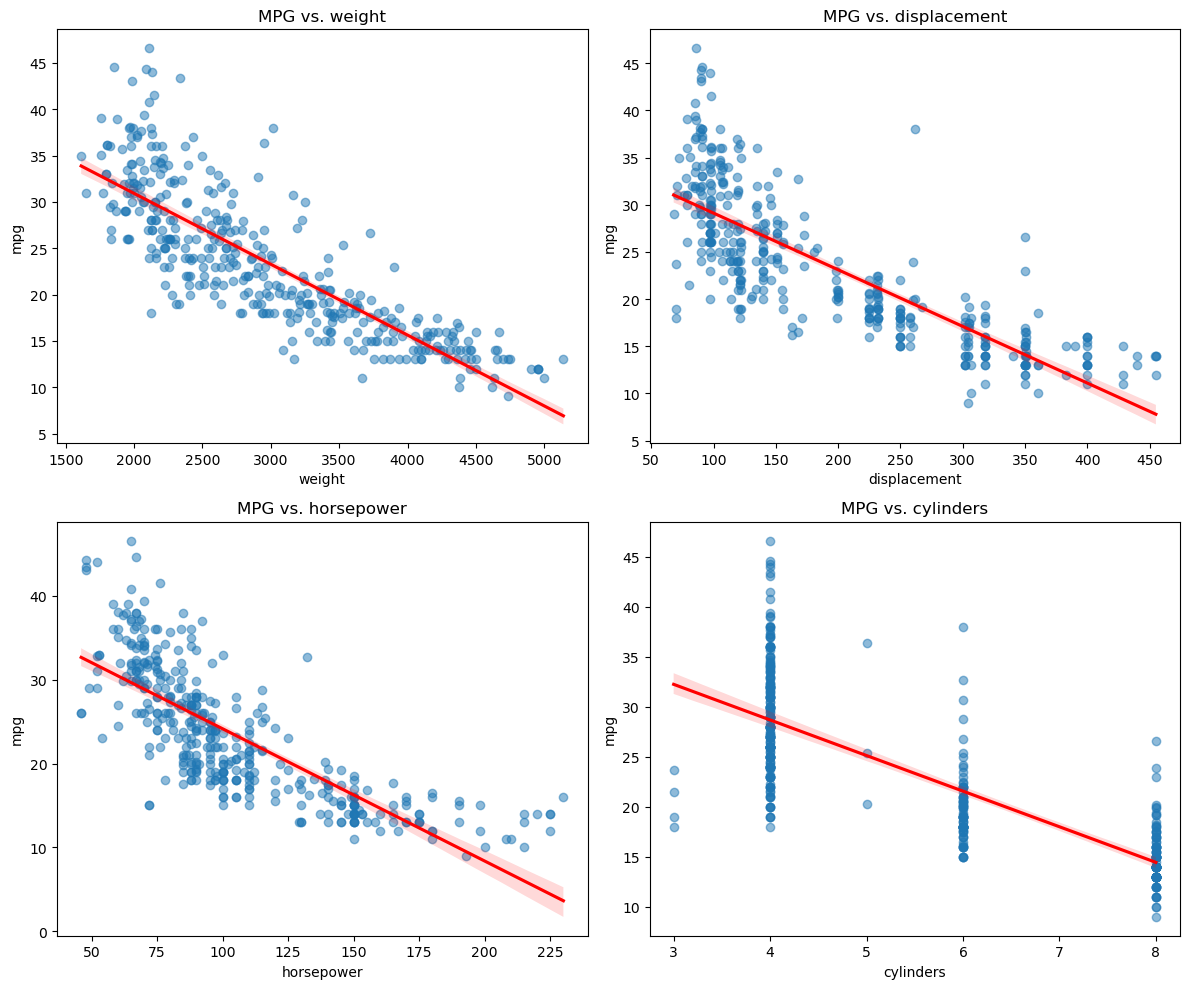

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter plots with regression lines
features_to_plot = ["weight", "displacement", "horsepower", "cylinders"]
for ax, feature in zip(axes.flat, features_to_plot):
    sns.regplot(data=df, x=feature, y="mpg", ax=ax, scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
    ax.set_title(f"MPG vs. {feature}")

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "MPG_by_key_characteristics.png"), dpi=300, bbox_inches='tight')



# PCA

## PCA 1

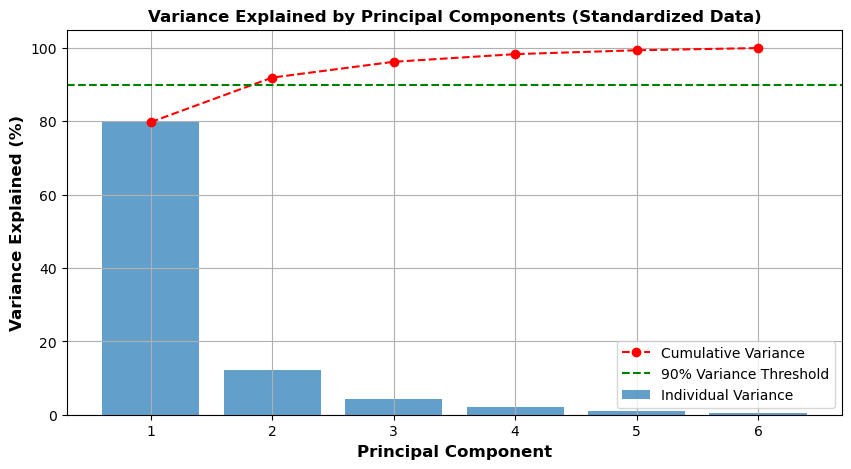

In [16]:
# Convert DataFrame to a NumPy array
data_matrix = df_continous.to_numpy()


# Standardize the data
mean_vector = data_matrix.mean(axis=0)
std_vector = data_matrix.std(axis=0)

# Avoid division by zero in case any feature has zero variance
std_vector[std_vector == 0] = 1

Z = (data_matrix - mean_vector) / std_vector  # Standardized data matrix (mean centering)

# Perform Singular Value Decomposition (SVD)
U, S, Vt = svd(Z, full_matrices=False)

# scipy.linalg.svd returns "Vt", which is the Hermitian (transpose)
# of the vector Vt. So, for us to obtain the correct V, we transpose:
V = Vt.T

# Compute the variance explained by each principal component
rho = (S ** 2) / np.sum(S ** 2)

# Compute the cumulative variance explained
cumulative_rho = np.cumsum(rho)

# Plot the variance explained by each principal component
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(rho) + 1), rho * 100, alpha=0.7, label="Individual Variance")
plt.plot(range(1, len(cumulative_rho) + 1), cumulative_rho * 100, marker="o", linestyle="--", color="r", label="Cumulative Variance")

# Add threshold line at 90% cumulative variance
plt.axhline(y=90, color='g', linestyle='--', label="90% Variance Threshold")

plt.xlabel("Principal Component", fontsize=12, fontweight='bold')
plt.ylabel("Variance Explained (%)", fontsize=12, fontweight='bold')
plt.title("Variance Explained by Principal Components (Standardized Data)", fontsize=12, fontweight='bold')
plt.legend()
plt.grid()

plt.savefig(os.path.join(save_dir, "Variance_principal_components.png"), dpi=300, bbox_inches='tight')

## PCA 2

In [17]:
# Extract the first two principal component vectors
PC1_vector = V[:, 0]  # First principal component
PC2_vector = V[:, 1]  # Second principal component

# Print the vectors
print("Principal Component 1 (PC1) Vector:")
print("- PC1 mainly separates heavy, high-displacement cars (left side) from lighter, fuel-efficient cars (right side).")
print(PC1_vector)

print("\nPrincipal Component 2 (PC2) Vector:")
print("-  PC2 captures differences in acceleration and weight, separating fast-accelerating cars (top side) from slower ones (bottom side).")

print(PC2_vector)

# Store the vectors in pandas dataframe
components_df = pd.DataFrame(
    np.column_stack((PC1_vector, PC2_vector)),
    index=df_continous.columns,
    columns=['PC1', 'PC2']
)


Principal Component 1 (PC1) Vector:
- PC1 mainly separates heavy, high-displacement cars (left side) from lighter, fuel-efficient cars (right side).
[ 0.39897309 -0.43061523 -0.44353136 -0.43412172 -0.43010308  0.29192568]

Principal Component 2 (PC2) Vector:
-  PC2 captures differences in acceleration and weight, separating fast-accelerating cars (top side) from slower ones (bottom side).
[ 0.24483454 -0.14831406 -0.10849714  0.1661584  -0.28609545 -0.8926523 ]


## PCA 3

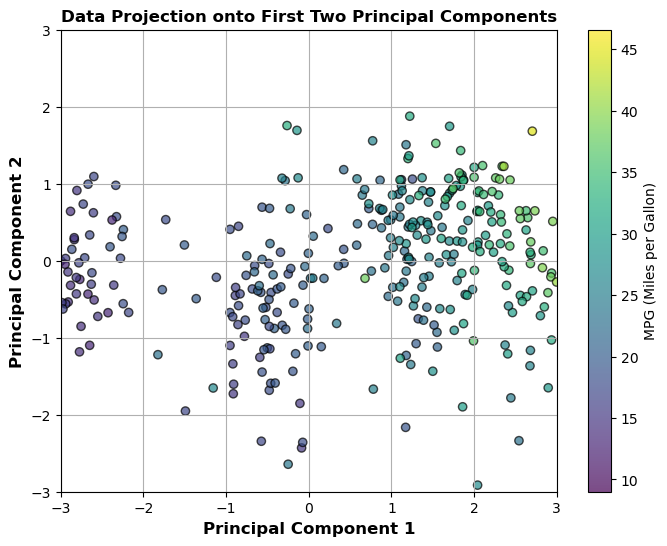

In [18]:
# Choose the first two principal components for 2D visualization
PC1 = U[:, 0] * S[0]  # First principal component
PC2 = U[:, 1] * S[1]  # Second principal component

plt.figure(figsize=(8, 6))
scatter = plt.scatter(PC1, PC2, c=df['mpg'], cmap='viridis', edgecolors='k', alpha=0.7)
plt.colorbar(scatter, label='MPG (Miles per Gallon)')
plt.xlabel("Principal Component 1", fontsize=12, fontweight='bold')
plt.ylabel("Principal Component 2", fontsize=12, fontweight='bold')
plt.title("Data Projection onto First Two Principal Components", fontsize=12, fontweight='bold')
plt.grid()

# Set uniform axis limits
plt.xlim(-3, 3)  # Set x-axis limits
plt.ylim(-3, 3)  # Set y-axis limits

plt.savefig(os.path.join(save_dir, "Data_projection_principal_components.png"), dpi=300, bbox_inches='tight')
df.to_csv('data_cleaned.txt', sep='\t', index=False, na_rep='NaN')

# Correlation

In [19]:
from scipy.stats import zscore

df_standerized = zscore(df_continous, ddof=1)
corr_matrix = df_standerized.corr()

# Correlation matrix as a heatmaprn
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
# plt.title("Correlation Matrix")
plt.savefig(os.path.join(save_dir, "correlation.png"), dpi=300, bbox_inches='tight')
plt.show()

# Table
print("Correlation Matrix:")
print(corr_matrix)

AttributeError: 'numpy.ndarray' object has no attribute 'corr'